In [5]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import spacy
from wordcloud import WordCloud

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

try:
    nlp = spacy.load("fr_core_news_sm")
except OSError:
    print("Modèle français absent. Installation en cours...")
    spacy.cli.download("fr_core_news_sm")
    nlp = spacy.load("fr_core_news_sm")

print('Environnement prêt.')

Environnement prêt.


### Partie 1 — Exploration & Prétraitement des données

#### 1.1 Chargement et exploration

In [6]:
#Chargement des données :
data_path = "C:\\Users\\Ce PC\\TALDR_TEST_TECHNIQUE_AFRICLANG\\data\\dataset_nlp_test_tal.csv"
raw = pd.read_csv(data_path)
df = raw.copy()

print("Dimmensions du dataset :\n")
print(df.shape)
print("Aperçu du dataset \n")
print(df.head())
print("Informations sur le dataset:\n")
print(df.info())


Dimmensions du dataset :

(150, 3)
Aperçu du dataset 

   id                                              texte       categorie
0   1  Manque total de communication entre les services.  Insatisfaction
1   2  Il serait bien de proposer des tutoriels vidéo...      Suggestion
2   3  Envoyer des SMS de confirmation lors de chaque...      Suggestion
3   4  Prévoir des interprètes pour les citoyens ne p...      Suggestion
4   5  Le formulaire en ligne plante au moment de la ...  Insatisfaction
Informations sur le dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         150 non-null    int64 
 1   texte      150 non-null    object
 2   categorie  150 non-null    object
dtypes: int64(1), object(2)
memory usage: 3.6+ KB
None


In [7]:
pd.set_option('display.max_colwidth', None)
df[["texte","categorie"]].sample(15)

,texte,categorie
136,Le système informatique est constamment en panne.,Insatisfaction
111,Mon problème a été résolu en une seule visite.,Satisfaction
143,Le système de prise de rendez-vous en ligne est très pratique.,Satisfaction
55,"Les infrastructures ont été bien améliorées, bravo aux équipes.",Satisfaction
95,Trop de paperasse pour une simple demande de pièce.,Insatisfaction
86,Augmenter le nombre de guichets ouverts aux heures de pointe.,Suggestion
123,"Mauvaise gestion de la foule, risque de bousculade.",Insatisfaction
34,Mettre en réseau les différentes mairies pour un meilleur partage des données.,Suggestion
74,"Service de première classe, je n'ai aucune remarque négative.",Satisfaction
13,Numériser les archives pour retrouver rapidement les anciens dossiers.,Suggestion


Text(0.5, 1.0, 'Distributions des classes de la colonne categorie.')

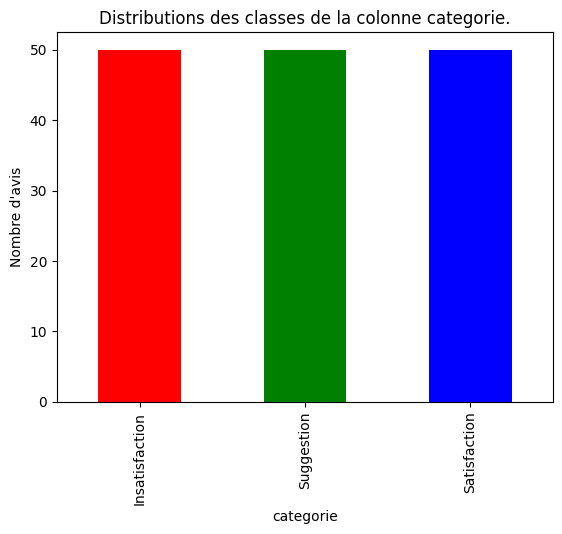

In [8]:
#Distribution des classes

classes_distributions = df['categorie'].value_counts()
classes_distributions.plot(kind="bar",color = ['red','green','blue'])
plt.ylabel("Nombre d'avis")
plt.title("Distributions des classes de la colonne categorie.")

#### On remarque que les classes de notre dataset sont equilibrés c'est a dire **50** observations pour chaque classes

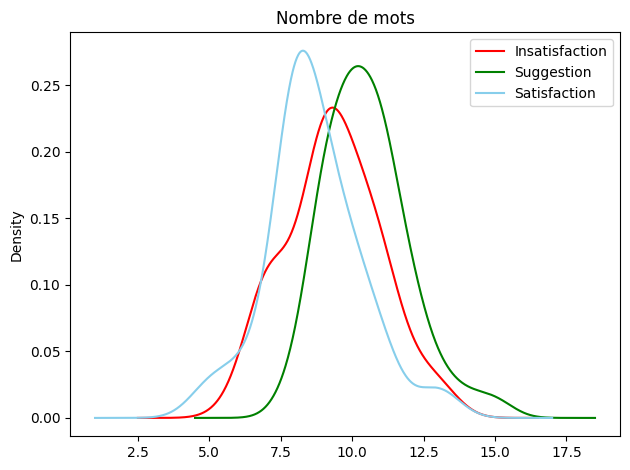

Longueur moyenne des mots par categorie:



categorie
Insatisfaction     9.34
Satisfaction       8.68
Suggestion        10.50
Name: nb_mots, dtype: float64

In [9]:

df['nb_mots'] = df['texte'].apply(lambda x: len(x.split()))

df[df['categorie'] == 'Insatisfaction']['nb_mots'].plot(kind='kde', color='red', label='Insatisfaction')
df[df['categorie'] == 'Suggestion']['nb_mots'].plot(kind='kde', color='green', label='Suggestion')
df[df['categorie'] == 'Satisfaction']['nb_mots'].plot(kind='kde', color='skyblue', label='Satisfaction')

plt.title('Longueur des avis (nombre de mots)')
plt.title('Nombre de mots')
plt.legend()
plt.tight_layout()
plt.show()

#Longueur moyenne des textes par categorie

print("Longueur moyenne des mots par categorie:\n")
df.groupby("categorie")["nb_mots"].mean()

#### 1.2 Nettoyage du texte

In [10]:
#Mise du texte en miniscule
def to_lower(texte):
    texte = texte.lower()
    return texte

df['texte'] = df['texte'].apply(to_lower)
df.head(5)

,id,texte,categorie,nb_mots
0,1,manque total de communication entre les services.,Insatisfaction,7
1,2,il serait bien de proposer des tutoriels vidéo pour les démarches en ligne.,Suggestion,13
2,3,envoyer des sms de confirmation lors de chaque étape du traitement.,Suggestion,11
3,4,prévoir des interprètes pour les citoyens ne parlant pas le français.,Suggestion,11
4,5,le formulaire en ligne plante au moment de la soumission.,Insatisfaction,10


In [11]:
#suprimer la ponctuation les chiffres et les caracteres speciaux

def clean(texte):
    texte = re.sub(r'[^\w\s]',   ' ', texte)  # ponctuation et caractères spéciaux
    texte = re.sub(r'\d+',       ' ', texte)  # Chiffres
    return texte

df['texte'] = df['texte'].apply(clean)
df.sample(5)
    


,id,texte,categorie,nb_mots
55,56,les infrastructures ont été bien améliorées bravo aux équipes,Satisfaction,9
38,39,un système de feedback à la sortie permettrait d améliorer continuellement,Suggestion,10
80,81,des formations régulières du personnel amélioreraient la qualité du service,Suggestion,10
47,48,former des citoyens relais dans chaque quartier pour aider leurs voisins,Suggestion,11
49,50,je n ai reçu aucun accusé de réception de ma demande,Insatisfaction,10


In [12]:
#Strategie pour les mots en ewe en mina:


 Puise que nous travaillons avec des données en français la présence de mot ewe pourrai faire baisser la precision de nos modeles, une stratégie serai la suppression definitive. 
 On peut néanmoins envisager de traduire les mots ewe en français , via un modele de traduction ce qui n'est pas vraiment adapter pour le contexte, ou substituer les mots ewe pas un dictionaire de mot prédefinit.

In [13]:
# Suppression des stopwords
import nltk
nltk.download ('stopwords')
from nltk.corpus import stopwords


#Taille des mots vides dans le vocaulaire
stop_nltk = set ( stopwords.words('french') )
print ( len ( stop_nltk ) )

#Liste des mots vides
stop_nltk = list ( stop_nltk )
print (stop_nltk[:15])


157
['fut', 'soyez', 'nous', 'leur', 'mes', 'la', 'avais', 'j', 'l', 'furent', 'nos', 'lui', 'd', 'serai', 'auras']


[nltk_data] Downloading package stopwords to C:\Users\Ce
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Deux principaux bibliothèques fournissent une liste pré -établi des mots vides : `nltk` et `spacy`
nltk qui est assez compatible avec le français et gere mieux la subtilité de la langue française.
Nous allons constituer une liste aggreger des stopword des deux bibliotheques pour avoir une liste exhaustive.

In [14]:
import spacy

nlp = spacy.load('fr_core_news_sm')

stop_spacy = nlp.Defaults.stop_words
print(f'SpaCy : {len(stop_spacy)} stopwords')
print(f'Stopwords : {list(stop_spacy)[:15]}')

SpaCy : 507 stopwords
Stopwords : ['cinquième', 'certaine', 'nôtres', 'quinze', 'celle-ci', 'etre', 'a', 'hue', 'touchant', 't’', 'allons', 'sauf', 'notre', 'anterieur', 'quarante']


In [15]:
stop_fr = set(stop_nltk) | stop_spacy  # union des deux listes
print(f'Total : {len(stop_fr)} stopwords')

Total : 579 stopwords


In [16]:
#Suppression des stop words
def removes_stops(texte, stop_fr):
    tokens = texte.split()
    return [t for t in tokens if t.lower() not in stop_fr]

In [17]:
# Prendre une copie du dataset original pour pouvoir comparer
df2 = raw.copy()

print("Avant suppression des mots vides :")
display(df2.head(3))

df['tokens'] = df['texte'].apply(lambda x: removes_stops(x, stop_fr))

print("\nAprès suppression des mots vides :")
display(df[['texte', 'tokens']].head(3))

Avant suppression des mots vides :


,id,texte,categorie
0,1,Manque total de communication entre les services.,Insatisfaction
1,2,Il serait bien de proposer des tutoriels vidéo pour les démarches en ligne.,Suggestion
2,3,Envoyer des SMS de confirmation lors de chaque étape du traitement.,Suggestion



Après suppression des mots vides :


,texte,tokens
0,manque total de communication entre les services,"[manque, total, communication, services]"
1,il serait bien de proposer des tutoriels vidéo pour les démarches en ligne,"[bien, proposer, tutoriels, vidéo, démarches, ligne]"
2,envoyer des sms de confirmation lors de chaque étape du traitement,"[envoyer, sms, confirmation, étape, traitement]"


#### 1.3 Visualisations

In [25]:
#nuage de mots (wordcloud) par catégorie
figures_dir = "C:\\Users\\Ce PC\\TALDR_TEST_TECHNIQUE_AFRICLANG\\figures_dir"
def wordcloud(categorie):
    words = df[df['categorie'] == categorie]['tokens'].replace("", pd.NA).dropna().astype(str).tolist()
    if not words:
        print(f'Aucun mot pour la categorie {categorie}')
        return

    text = " ".join(words)
    wc = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'Wordcloud pour la catégorie : {categorie}')
    plt.axis('off')
    out = figures_dir / f'wordcloud_{categorie}.png'
    plt.tight_layout()
    plt.savefig(out, dpi=200)


Wordcloud de la categorie Insatisfaction :


Wordcloud de la categorie Suggestion :
Wordcloud de la categorie Satisfaction :


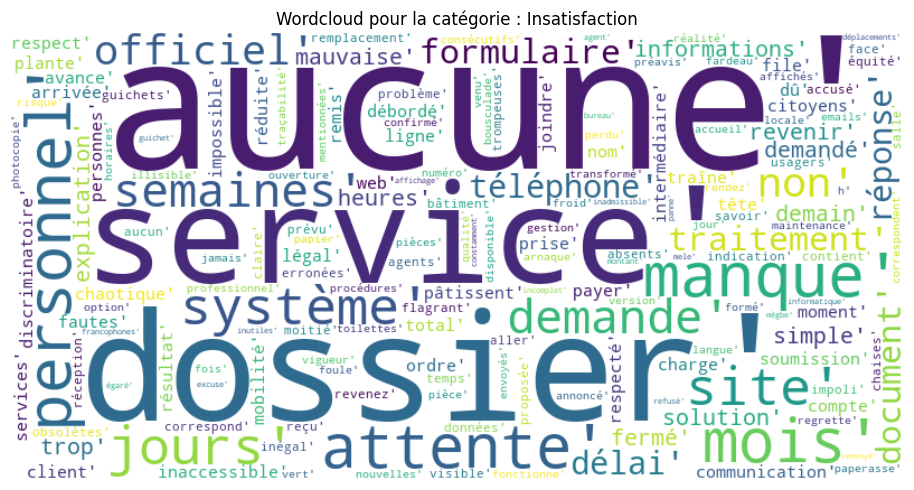

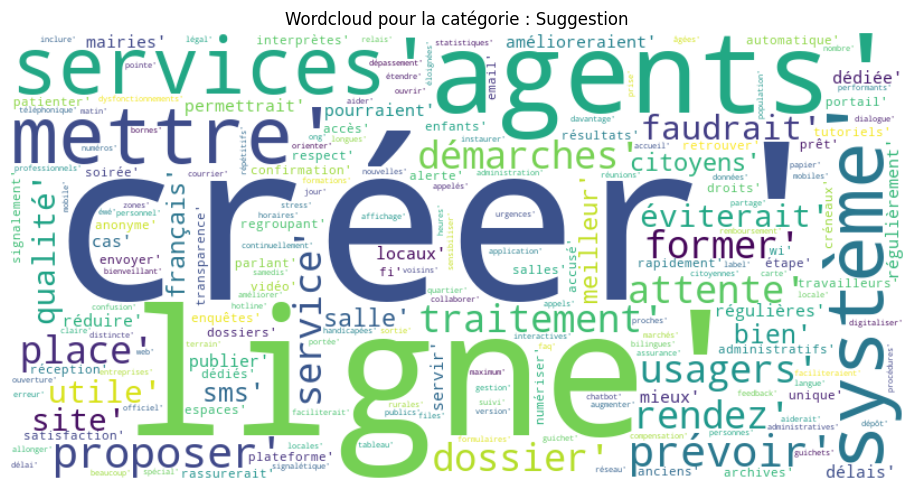

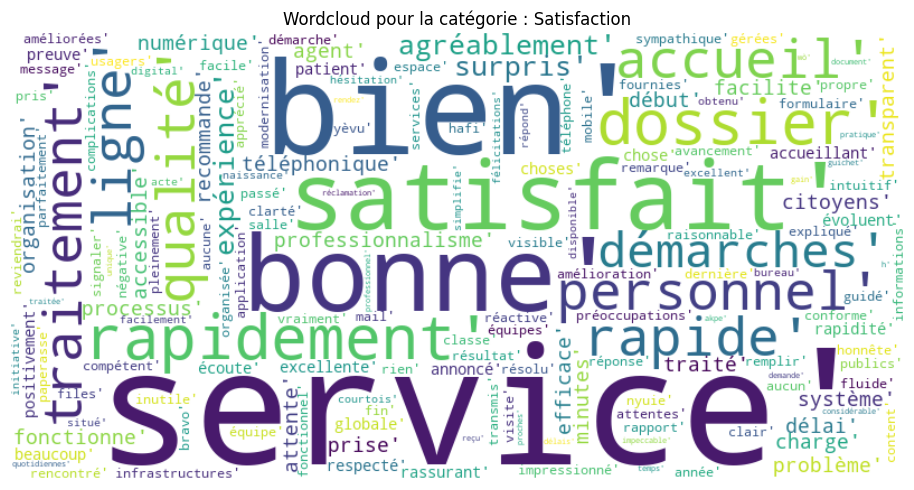

In [36]:
from pathlib import Path

categories = ["Insatisfaction","Suggestion","Satisfaction"]

for categorie in categories:
    print(f'Wordcloud de la categorie {categorie} :')
    figures_dir = Path(figures_dir)
    figures_dir.mkdir(parents=True, exist_ok=True)

    wordcloud(categorie)

In [32]:
#les 15 termes les plus fréquents par catégorie

top_15_Insatisfaction = df[df['categorie'] == 'Insatisfaction']['tokens'].explode().value_counts().head(15)
top_15_Suggestion = df[df['categorie'] == 'Suggestion']['tokens'].explode().value_counts().head(15)
top_15_Satisfaction = df[df['categorie'] == 'Satisfaction']['tokens'].explode().value_counts().head(15)
top_15 = {"Insatisfaction":top_15_Insatisfaction, "Suggestion":top_15_Suggestion, "Satisfaction":top_15_Satisfaction}
for categorie,top in top_15.items():
    print("\n les 15 termes les plus fréquents pour la catégorie ", categorie)
    print(top)


 les 15 termes les plus fréquents pour la catégorie  Insatisfaction
tokens
aucune        10
dossier        6
service        5
personnel      4
attente        4
mois           4
manque         4
semaines       3
système        3
jours          3
non            3
officiel       3
demande        3
site           3
traitement     2
Name: count, dtype: int64

 les 15 termes les plus fréquents pour la catégorie  Suggestion
tokens
créer         6
ligne         5
services      5
agents        5
système       5
mettre        5
prévoir       4
proposer      4
démarches     3
usagers       3
former        3
traitement    3
attente       3
place         3
dossier       3
Name: count, dtype: int64

 les 15 termes les plus fréquents pour la catégorie  Satisfaction
tokens
service       14
bien           8
bonne          5
satisfait      4
rapidement     4
dossier        4
accueil        3
rapide         3
démarches      3
qualité        3
personnel      3
traitement     3
ligne          3
expérience

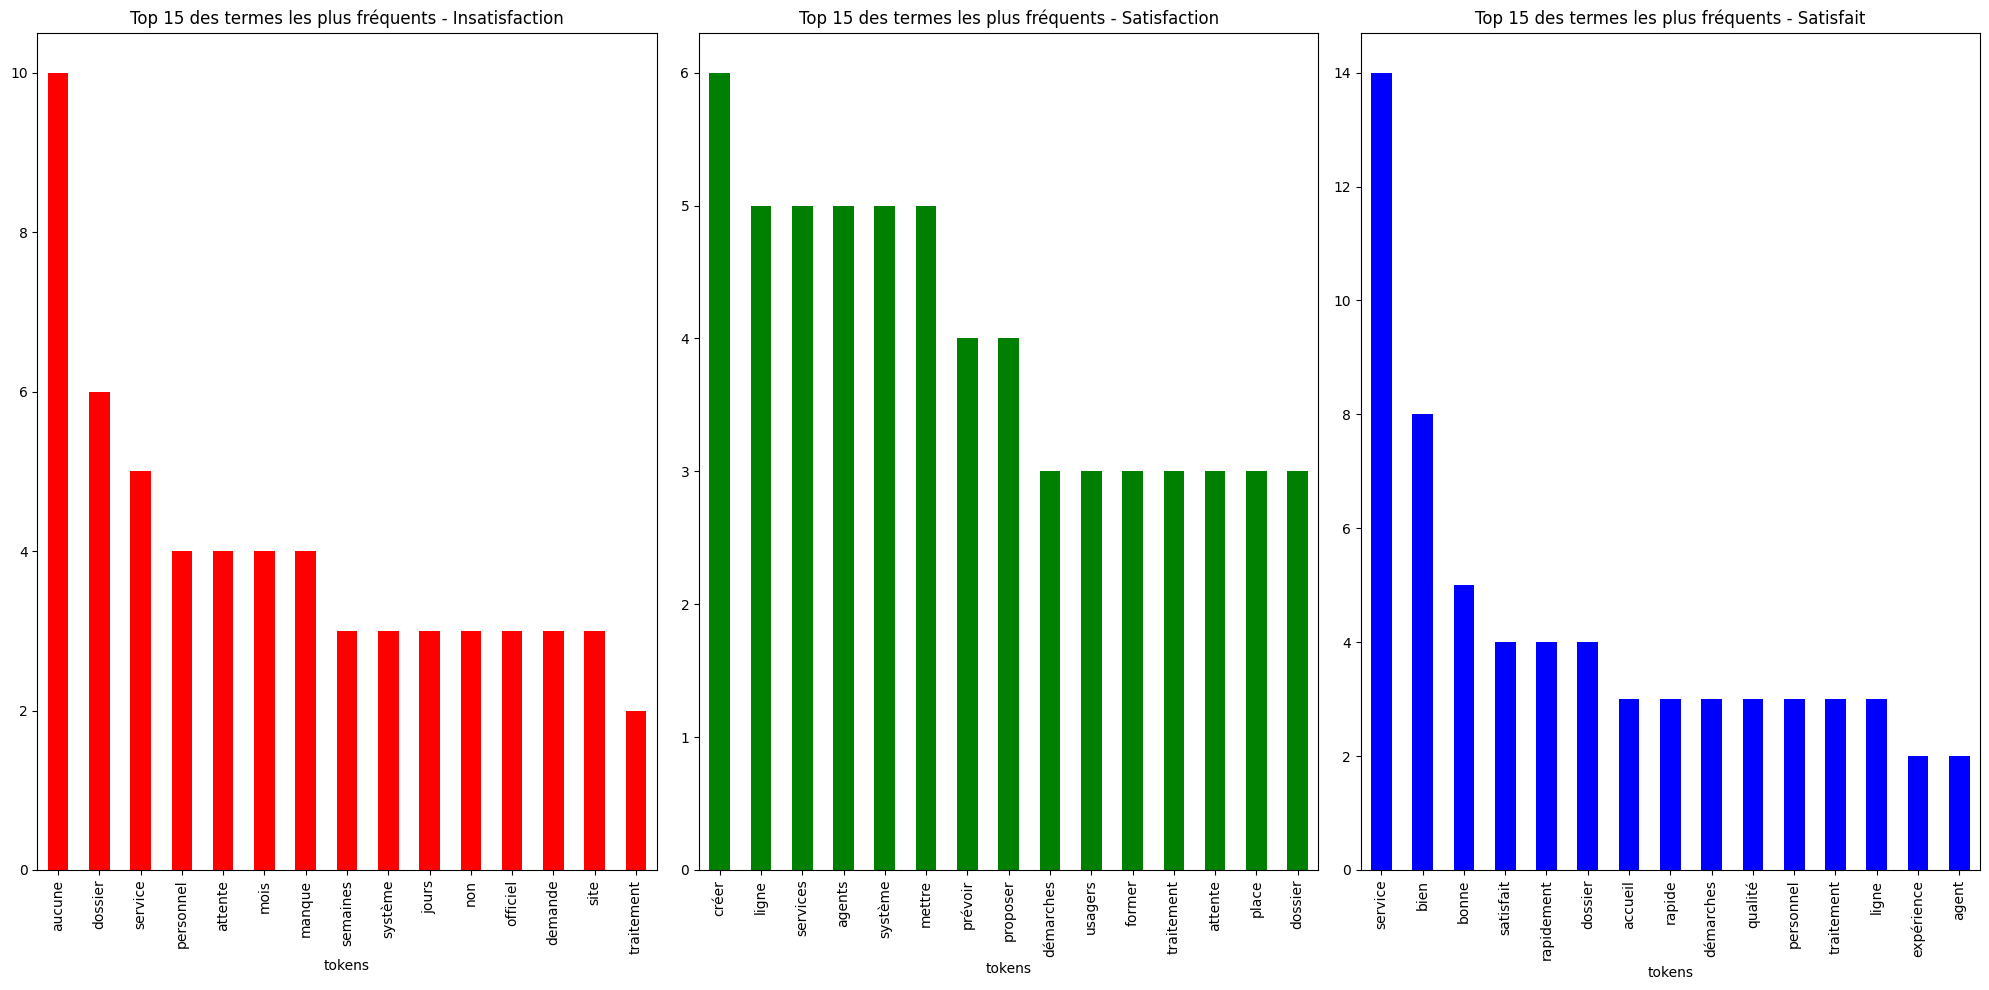

In [37]:
# AFfichage des termes les plus fréquents par categorie
fig,axes = plt.subplots(1,3,figsize=(20, 10))
top_15_Insatisfaction.plot(kind='bar',ax=axes[0], color='red', title='Top 15 des termes les plus fréquents - Insatisfaction')
top_15_Suggestion.plot(kind='bar',ax=axes[1], color='green', title='Top 15 des termes les plus fréquents - Satisfaction')
top_15_Satisfaction.plot(kind='bar',ax=axes[2], color='blue', title='Top 15 des termes les plus fréquents - Satisfait')

out = figures_dir / f'Frequence_termes_par_categorie.png'
plt.tight_layout()
plt.savefig(out, dpi=200)
plt.show()

### Partie 2 — Modélisation

#### 2.1 Vectorisation
Les modèles de machine learning travaillent avec des **nombres**, pas du texte. La vectorisation transforme chaque texte en un vecteur numérique. ILs existe trois principale approche dont le choix depend du travail demander et du contexte :

| Méthode | Vecteur | Capture le sens ? |
|---|---|---|
| Bag of Words | Creux (sparse) | Non |
| TF-IDF | Creux (sparse) | Non (fréquence) |
| Embeddings | Dense | Oui |

Nous allons explorer le TF-IDF en baseline puis tester des Embeddings avant de conclure et de faire un choix de la meilleur strategie.

##### a. TF-IDF

Le **TF-IDF** (*Term Frequency – Inverse Document Frequency*) pondère chaque mot selon sa fréquence dans le document (TF) et sa rareté dans le corpus (IDF). Un mot très fréquent dans un texte mais rare dans les autres obtient un score élevé — contrairement aux mots courants comme "le", "de", etc.

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
textes = df['tokens'].apply(lambda tokens: ' '.join(tokens))

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(textes)

print(f"Taille de la matrice TF-IDF : {X_tfidf.shape}")
print(f"Exemple de mots : {tfidf.get_feature_names_out()[:10]}")

Taille de la matrice TF-IDF : (150, 461)
Exemple de mots : ['absents' 'accessible' 'accompagnement' 'accueil' 'accueillant' 'accusé'
 'accès' 'acte' 'administratifs' 'administration']


##### b. Bag of Words (BoW)

Le **Bag of Words** construit un vocabulaire global puis représente chaque texte par le **nombre d'occurrences** de chaque mot de ce vocabulaire. L'ordre des mots est totalement ignoré.

In [39]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(textes)

print(f"Taille de la matrice BoW : {X_bow.shape}")
print(f"Exemple de mots du vocabulaire : {bow.get_feature_names_out()[:10]}")

Taille de la matrice BoW : (150, 461)
Exemple de mots du vocabulaire : ['absents' 'accessible' 'accompagnement' 'accueil' 'accueillant' 'accusé'
 'accès' 'acte' 'administratifs' 'administration']


#### c. Embeddings — Word2Vec

**Word2Vec** est un modèle neuronal qui apprend des représentations vectorielles denses (*embeddings*) à partir du contexte des mots dans le corpus. Contrairement à BoW/TF-IDF, il capture le **sens** : *film* et *cinéma* auront des vecteurs proches.

Deux architectures d'entraînement existent :

| Architecture | Principe | Adapté à |
|---|---|---|
| **CBOW** | Prédit le mot central à partir des mots du contexte | Grands corpus |
| **Skip-gram** | Prédit les mots du contexte à partir du mot central | Petits corpus, mots rares |


Nous choisissons de partir sur wordvec en baseline mais il existe divers modeles d'embbbedings encore plus performants.

In [40]:
from gensim.models import Word2Vec

# Corpus : liste de listes de tokens (déjà calculé à l'étape Tokenisation)
corpus = df['tokens'].tolist()

# CBOW (sg=0) : prédit le mot central à partir des mots environnants
cbow = Word2Vec(sentences=corpus, vector_size=100, window=5, min_count=2, sg=0, epochs=10)

print(f"Vocabulaire : {len(cbow.wv)} mots  |  Dimension : {cbow.vector_size}")
print(f"\nVecteur de 'acceuil' (5 premières dims) : {cbow.wv['acceuil'][:5].round(3)}")
print(f"\nMots les plus proches de 'acceuil' (CBOW) :")
for mot, score in cbow.wv.most_similar('acceuil', topn=5):
    print(f"  {mot:20} {score:.3f}")

  error: subprocess-exited-with-error
  
  × Building wheel for gensim (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [716 lines of output]
      C:\Users\Ce PC\AppData\Local\Temp\pip-build-env-wnnapevi\overlay\Lib\site-packages\setuptools\_distutils\dist.py:318: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      C:\Users\Ce PC\AppData\Local\Temp\pip-build-env-wnnapevi\overlay\Lib\site-packages\setuptools\_distutils\dist.py:318: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-314\gensim
      copying gensim\downloader.py -> build\lib.win-amd64-cpython-314\gensim
      copying gensim\interfaces.py -> build\lib.win-amd64-cpython-314\gensim
      copying gensim\matutils.py -> build\lib.win-amd64-cpython-314\gensim
      copying gensim\nosy.py -> build\lib.win-amd64-cpython-314\gensim
   

ModuleNotFoundError: No module named 'gensim'

#### Nous partons sur du TF-IDF en baseline

In [41]:
#SPlit de l'ensemble de données en ensembles d'entraînement et de test
from sklearn.model_selection import train_test_split
y = df['categorie']

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

#### 2.2 Entraînement

In [42]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             silhouette_score)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

In [44]:
#Naives bayes
naive = MultinomialNB()
naive.fit(X_train, y_train)

#Regression logistic
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

#support vector machines
svm = LinearSVC(max_iter=10000)
svm.fit(X_train, y_train)


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


#### 2.3 Évaluation

In [49]:
def evaluate( model, X_test, y_test, model_name: str):
    """
        Évalue un modèle et affiche les métriques.

        Affiche :
        - Accuracy
        - F1-score macro et pondéré
        - Rapport de classification complet
        - Matrice de confusion (graphique)

        Sauvegarde : figures/partie_c/confusion_{model_name}.png

        Args:
            model      : Modèle entraîné
            X_test     : Données de test
            y_test     : Étiquettes réelles
            model_name : Nom du modèle (pour le titre et le nom de fichier)
    """
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    print(f"Évaluation {model_name}:")
    print(classification_report(y_test, y_pred))

        # matrice de confusion
    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f'Matrice de confusion - {model_name}')
    plt.savefig(figures_dir / f'confusion_{model_name.replace(" ","_")}.png')
    plt.close()
    results = {}
        # stocker les métriques
    results[model_name] = {
            'accuracy': report.get('accuracy', None),
            'f1_macro': report.get('macro avg', {}).get('f1-score', None),
            'f1_weighted': report.get('weighted avg', {}).get('f1-score', None),
        }
    return results

def compare_models(results):
    """
        Affiche un tableau comparatif des performances de tous les modèles
        entraînés (accuracy, F1-macro, F1-pondéré).

        Sauvegarde : figures_dir/comparaison_classifieurs.png
    """
    df = pd.DataFrame(results).T
    print(df)
    plt.figure()
    df[['accuracy','f1_macro','f1_weighted']].plot(kind='bar')
    plt.tight_layout()
    plt.savefig(figures_dir / 'comparaison_classifieurs.png')
    plt.show()


In [51]:
modeles = {"naives-bayes":naive,"logistic Reegression": logreg, "svm":svm}
results = {}
for name,modele in modeles.items():
    print(f"debut de l'evaluation du modele :{name} : \n")
    print("========================================")
    results.update(evaluate(modele, X_test, y_test, name))
    


debut de l'evaluation du modele :naives-bayes : 

Évaluation naives-bayes:
                precision    recall  f1-score   support

Insatisfaction       0.44      0.36      0.40        11
  Satisfaction       0.45      0.42      0.43        12
    Suggestion       0.50      0.71      0.59         7

      accuracy                           0.47        30
     macro avg       0.47      0.50      0.47        30
  weighted avg       0.46      0.47      0.46        30

debut de l'evaluation du modele :logistic Reegression : 

Évaluation logistic Reegression:
                precision    recall  f1-score   support

Insatisfaction       0.56      0.45      0.50        11
  Satisfaction       0.62      0.42      0.50        12
    Suggestion       0.46      0.86      0.60         7

      accuracy                           0.53        30
     macro avg       0.55      0.58      0.53        30
  weighted avg       0.56      0.53      0.52        30

debut de l'evaluation du modele :svm : 

Éva

In [52]:
#Comparaisons des modèles dans un tableau de synthèse
compare_models(results)

                      accuracy  f1_macro  f1_weighted
naives-bayes          0.466667  0.474339     0.457835
logistic Reegression  0.533333  0.533333     0.523333
svm                   0.533333  0.533670     0.531145


<Figure size 640x480 with 0 Axes>

 On constate que les performances des modeles sont globalement assez faible , la raison vient peut etre de la vectorisation, pour augmenter les performances nous allons nous tourner vers un model **d'embeddings pré entrainer** et le fine tuner sur nos données.
 1. LA premiere piste d'amelioration est de tenter un fine tunning d'un modele multilingue préentrainé.
 2. FAire une tokenization un peut plus pousser.
 3. Tester d'autres modeles de classification et les evaluer pour observer les performances.